
# Method 6: Agarwal's Model

Train Model →  (7 → 64 → 32 → 1) 


In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import clear_output
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from mcp_tool import MCPTool

sns.set_theme(style="darkgrid")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cpu


In [2]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed(0)
    torch.cuda.manual_seed_all(0)
if hasattr(torch.backends, "cudnn"):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [3]:
DATA_DIR = Path("./classification_data")
CHECKPOINT_DIR = Path("./agarwal_checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = Path("./agarwal_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

X_train = np.load(DATA_DIR / "X_train.npy").astype(np.float32)
X_val = np.load(DATA_DIR / "X_val.npy").astype(np.float32)
X_test = np.load(DATA_DIR / "X_test.npy").astype(np.float32)
y_train = np.load(DATA_DIR / "y_train.npy").astype(np.int64)
y_val = np.load(DATA_DIR / "y_val.npy").astype(np.int64)
y_test = np.load(DATA_DIR / "y_test.npy").astype(np.int64)
bcu_samples = np.load(DATA_DIR / "bcu_samples.npy").astype(np.float32)

BATCH_SIZE = 2048
LEARNING_RATE = 1e-3
EPOCHS = 2500
PATIENCE = EPOCHS

print("train:", X_train.shape, y_train.shape)
print("val:", X_val.shape, y_val.shape)
print("test:", X_test.shape, y_test.shape)
print("bcu:", bcu_samples.shape)
print({"train_bll": int((y_train == 0).sum()), "train_fsrq": int((y_train == 1).sum())})


train: (1604, 7) (1604,)
val: (200, 7) (200,)
test: (201, 7) (201,)
bcu: (1115, 7)
{'train_bll': 1053, 'train_fsrq': 551}


In [4]:
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32).unsqueeze(1),
)
val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32).unsqueeze(1),
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32).unsqueeze(1),
)
bcu_dataset = TensorDataset(torch.tensor(bcu_samples, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
bcu_loader = DataLoader(bcu_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid(),
).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
}

model


Sequential(
  (0): Linear(in_features=7, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Linear(in_features=32, out_features=1, bias=True)
  (6): Sigmoid()
)

In [5]:
def compute_metrics(y_true, probabilities):
    predictions = (np.asarray(probabilities) >= 0.5).astype(int)
    y_true = np.asarray(y_true).astype(int)

    return {
        "accuracy": accuracy_score(y_true, predictions),
        "auc": roc_auc_score(y_true, probabilities),
        "precision_weighted": precision_score(y_true, predictions, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, predictions, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, predictions, average="weighted", zero_division=0),
    }


def collect_outputs(model, dataloader):
    model.eval()
    all_probabilities = []
    all_targets = []

    with torch.no_grad():
        for features_batch, targets_batch in dataloader:
            features_batch = features_batch.to(device)
            probabilities = model(features_batch)
            all_probabilities.append(probabilities.detach().cpu().numpy())
            all_targets.append(targets_batch.detach().cpu().numpy())

    all_probabilities = np.concatenate(all_probabilities, axis=0).reshape(-1)
    all_targets = np.concatenate(all_targets, axis=0).reshape(-1).astype(int)
    return all_probabilities, all_targets


def collect_outputs_unlabeled(model, dataloader):
    model.eval()
    all_probabilities = []

    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, (list, tuple)):
                features_batch = batch[0]
            else:
                features_batch = batch

            features_batch = features_batch.to(device)
            probabilities = model(features_batch)
            all_probabilities.append(probabilities.detach().cpu().numpy())

    all_probabilities = np.concatenate(all_probabilities, axis=0).reshape(-1)
    return all_probabilities


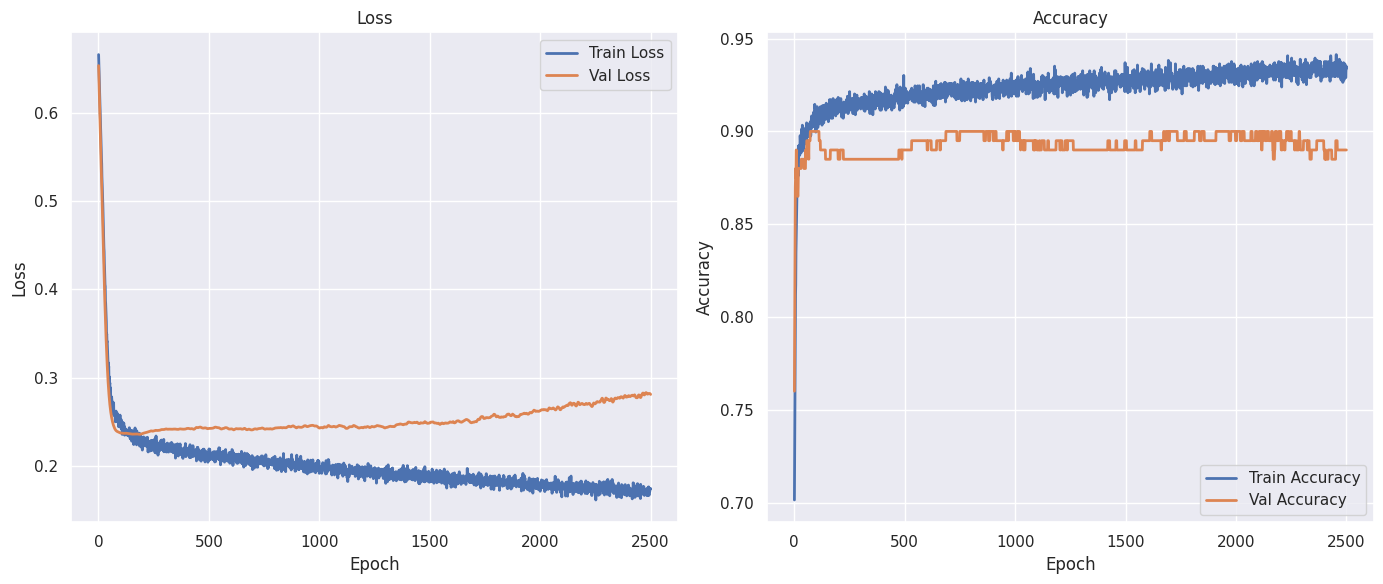

Epoch 2500/2500
train_loss=0.1746 | val_loss=0.2811 | train_acc=0.9339 | val_acc=0.8900


,train_loss,val_loss,train_accuracy,val_accuracy
2495,0.170962,0.282030,0.933915,0.89
2496,0.174701,0.282080,0.928928,0.89
2497,0.173385,0.281905,0.931421,0.89
2498,0.174389,0.281624,0.935162,0.89
2499,0.174613,0.281139,0.933915,0.89


In [6]:
best_val_loss = float("inf")
stale_epochs = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0
    train_probabilities = []
    train_targets = []

    for features_batch, targets_batch in train_loader:
        features_batch = features_batch.to(device)
        targets_batch = targets_batch.to(device)

        optimizer.zero_grad(set_to_none=True)
        probabilities = model(features_batch)
        loss = criterion(probabilities, targets_batch)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * targets_batch.size(0)
        train_probabilities.append(probabilities.detach().cpu().numpy())
        train_targets.append(targets_batch.detach().cpu().numpy())

    train_probabilities = np.concatenate(train_probabilities, axis=0).reshape(-1)
    train_targets = np.concatenate(train_targets, axis=0).reshape(-1).astype(int)
    train_predictions = (train_probabilities >= 0.5).astype(int)
    train_loss = train_loss_sum / len(train_loader.dataset)
    train_accuracy = accuracy_score(train_targets, train_predictions)

    model.eval()
    val_loss_sum = 0.0
    val_probabilities = []
    val_targets = []

    with torch.no_grad():
        for features_batch, targets_batch in val_loader:
            features_batch = features_batch.to(device)
            targets_batch = targets_batch.to(device)

            probabilities = model(features_batch)
            loss = criterion(probabilities, targets_batch)

            val_loss_sum += loss.item() * targets_batch.size(0)
            val_probabilities.append(probabilities.detach().cpu().numpy())
            val_targets.append(targets_batch.detach().cpu().numpy())

    val_probabilities = np.concatenate(val_probabilities, axis=0).reshape(-1)
    val_targets = np.concatenate(val_targets, axis=0).reshape(-1).astype(int)
    val_predictions = (val_probabilities >= 0.5).astype(int)
    val_loss = val_loss_sum / len(val_loader.dataset)
    val_accuracy = accuracy_score(val_targets, val_predictions)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)

    checkpoint_path = CHECKPOINT_DIR / f"weights_epoch_{epoch:04d}.pt"
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
        },
        checkpoint_path,
    )

    clear_output(wait=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    epoch_axis = np.arange(1, len(history["train_loss"]) + 1)

    axes[0].plot(epoch_axis, history["train_loss"], label="Train Loss", linewidth=2)
    axes[0].plot(epoch_axis, history["val_loss"], label="Val Loss", linewidth=2)
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epoch_axis, history["train_accuracy"], label="Train Accuracy", linewidth=2)
    axes[1].plot(epoch_axis, history["val_accuracy"], label="Val Accuracy", linewidth=2)
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"Epoch {epoch:04d}/{EPOCHS}")
    print(
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"train_acc={train_accuracy:.4f} | "
        f"val_acc={val_accuracy:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        stale_epochs = 0
    else:
        stale_epochs += 1

    if stale_epochs >= PATIENCE:
        print(f"Early stopping triggered after epoch {epoch}.")
        break

training_history_df = pd.DataFrame(history)
training_history_df.tail()


In [7]:
checkpoint_files = sorted(CHECKPOINT_DIR.glob("weights_epoch_*.pt"))
val_rows = []

for checkpoint_path in checkpoint_files:
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    val_loss_sum = 0.0
    val_probabilities = []
    val_targets = []

    with torch.no_grad():
        for features_batch, targets_batch in val_loader:
            features_batch = features_batch.to(device)
            targets_batch = targets_batch.to(device)

            probabilities = model(features_batch)
            loss = criterion(probabilities, targets_batch)

            val_loss_sum += loss.item() * targets_batch.size(0)
            val_probabilities.append(probabilities.detach().cpu().numpy())
            val_targets.append(targets_batch.detach().cpu().numpy())

    val_probabilities = np.concatenate(val_probabilities, axis=0).reshape(-1)
    val_targets = np.concatenate(val_targets, axis=0).reshape(-1).astype(int)
    val_predictions = (val_probabilities >= 0.5).astype(int)

    val_rows.append(
        {
            "epoch": int(checkpoint["epoch"]),
            "checkpoint_path": str(checkpoint_path),
            "loss": val_loss_sum / len(val_loader.dataset),
            "accuracy": accuracy_score(val_targets, val_predictions),
            "auc": roc_auc_score(val_targets, val_probabilities),
            "precision_weighted": precision_score(val_targets, val_predictions, average="weighted", zero_division=0),
            "recall_weighted": recall_score(val_targets, val_predictions, average="weighted", zero_division=0),
            "f1_weighted": f1_score(val_targets, val_predictions, average="weighted", zero_division=0),
            "precision_0": precision_score(val_targets, val_predictions, pos_label=0, zero_division=0),
            "precision_1": precision_score(val_targets, val_predictions, pos_label=1, zero_division=0),
            "recall_0": recall_score(val_targets, val_predictions, pos_label=0, zero_division=0),
            "recall_1": recall_score(val_targets, val_predictions, pos_label=1, zero_division=0),
            "f1_0": f1_score(val_targets, val_predictions, pos_label=0, zero_division=0),
            "f1_1": f1_score(val_targets, val_predictions, pos_label=1, zero_division=0),
        }
    )

val_results_df = pd.DataFrame(val_rows).sort_values("epoch").reset_index(drop=True)
val_results_df.to_csv(OUTPUT_DIR / "agarwal_validation_metrics.csv", index=False)

metrics_to_track = [
    "loss",
    "accuracy",
    "auc",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
    "precision_0",
    "precision_1",
    "recall_0",
    "recall_1",
    "f1_0",
    "f1_1",
]

best_rows = []
for metric_name in metrics_to_track:
    if metric_name == "loss":
        best_idx = val_results_df[metric_name].idxmin()
    else:
        best_idx = val_results_df[metric_name].idxmax()

    best_row = val_results_df.loc[best_idx]
    best_rows.append(
        {
            "metric": metric_name,
            "epoch": int(best_row["epoch"]),
            "score": float(best_row[metric_name]),
            "checkpoint_path": best_row["checkpoint_path"],
        }
    )

best_by_metric_df = pd.DataFrame(best_rows).set_index("metric")

print("Best validation epoch for each metric:")
best_by_metric_df


Best validation epoch for each metric:


,epoch,score,checkpoint_path
metric,,,
loss,189,0.235945,agarwal_checkpoints/weights_epoch_0189.pt
accuracy,73,0.900000,agarwal_checkpoints/weights_epoch_0073.pt
auc,1301,0.961190,agarwal_checkpoints/weights_epoch_1301.pt
precision_weighted,73,0.898810,agarwal_checkpoints/weights_epoch_0073.pt
recall_weighted,73,0.900000,agarwal_checkpoints/weights_epoch_0073.pt
f1_weighted,73,0.898980,agarwal_checkpoints/weights_epoch_0073.pt
precision_0,52,0.927536,agarwal_checkpoints/weights_epoch_0052.pt
precision_1,5,0.886364,agarwal_checkpoints/weights_epoch_0005.pt
recall_0,5,0.964286,agarwal_checkpoints/weights_epoch_0005.pt


Testing checkpoint from metric 'loss' at epoch 189
accuracy              0.910448
auc                   0.956553
precision_weighted    0.911510
recall_weighted       0.910448
f1_weighted           0.910876
dtype: float64

              precision    recall  f1-score   support

         BLL      0.943     0.930     0.936       142
        FSRQ      0.836     0.864     0.850        59

    accuracy                          0.910       201
   macro avg      0.889     0.897     0.893       201
weighted avg      0.912     0.910     0.911       201



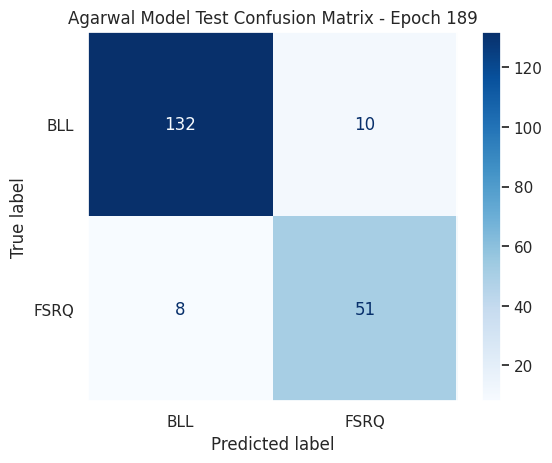

In [8]:
SELECTED_METRIC = "loss"
SELECTED_TEST_EPOCH = int(best_by_metric_df.loc[SELECTED_METRIC, "epoch"])
print(f"Testing checkpoint from metric '{SELECTED_METRIC}' at epoch {SELECTED_TEST_EPOCH}")

selected_checkpoint = CHECKPOINT_DIR / f"weights_epoch_{SELECTED_TEST_EPOCH:04d}.pt"
selected_state = torch.load(selected_checkpoint, map_location=device, weights_only=False)
model.load_state_dict(selected_state["model_state_dict"])
model.eval()

test_probabilities, test_targets = collect_outputs(model, test_loader)
test_predictions = (test_probabilities >= 0.5).astype(int)
test_metrics = compute_metrics(test_targets, test_probabilities)

print(pd.Series(test_metrics))
print()
print(classification_report(test_targets, test_predictions, target_names=["BLL", "FSRQ"], digits=3))

sns.set(style="dark")
cm = confusion_matrix(test_targets, test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["BLL", "FSRQ"])
disp.plot(cmap="Blues")
plt.title(f"Agarwal Model Test Confusion Matrix - Epoch {SELECTED_TEST_EPOCH}")
plt.savefig(OUTPUT_DIR / "AgarwalModel_Test_CM.png", dpi=300)
plt.show()

torch.save(
    {
        "epoch": SELECTED_TEST_EPOCH,
        "metric": SELECTED_METRIC,
        "model_state_dict": selected_state["model_state_dict"],
    },
    OUTPUT_DIR / "agarwal_best_val_loss.pt",
)


In [9]:
true_labels = np.asarray(test_targets).reshape(-1).astype(int)
pred_probs = np.asarray(test_probabilities).reshape(-1)

label_map = {0: "BLL", 1: "FSRQ"}

results_df = pd.DataFrame({
    "true_label": pd.Series(true_labels).map(label_map),
    "BLL": 1 - pred_probs,
    "FSRQ": pred_probs,
})

output_path = OUTPUT_DIR / "Agarwal_Test_Predictions.csv"
results_df.to_csv(output_path, index=False)

print("Saved to:", output_path.resolve())
results_df.head()


Saved to: /home/srinadb/BCU/BCUTorch/agarwal_outputs/Agarwal_Test_Predictions.csv


,true_label,BLL,FSRQ
0,FSRQ,0.004308,0.995692
1,BLL,0.990624,0.009376
2,BLL,0.669637,0.330363
3,BLL,0.990949,0.009051
4,BLL,0.963479,0.036521


In [10]:
model.load_state_dict(selected_state["model_state_dict"])
model.eval()

bcus_probabilities = collect_outputs_unlabeled(model, bcu_loader)
bcus_predictions = (bcus_probabilities >= 0.5).astype(int)


In [11]:
bcus_results_df = pd.DataFrame({
    "BLL": 1 - np.asarray(bcus_probabilities).reshape(-1),
    "FSRQ": np.asarray(bcus_probabilities).reshape(-1),
})

bcus_output_path = OUTPUT_DIR / "Agarwal_BCU_Predictions.csv"
bcus_results_df.to_csv(bcus_output_path, index=False)

print("Saved to:", bcus_output_path.resolve())
bcus_results_df.head()


Saved to: /home/srinadb/BCU/BCUTorch/agarwal_outputs/Agarwal_BCU_Predictions.csv


,BLL,FSRQ
0,0.891341,0.108659
1,0.985966,0.014034
2,0.954563,0.045437
3,0.979264,0.020736
4,0.947113,0.052887


### Testing

In [12]:
from utils import analyze_prediction_sets, create_and_plot_histograms_test_csv

BLL count : 140
FSRQ count: 61


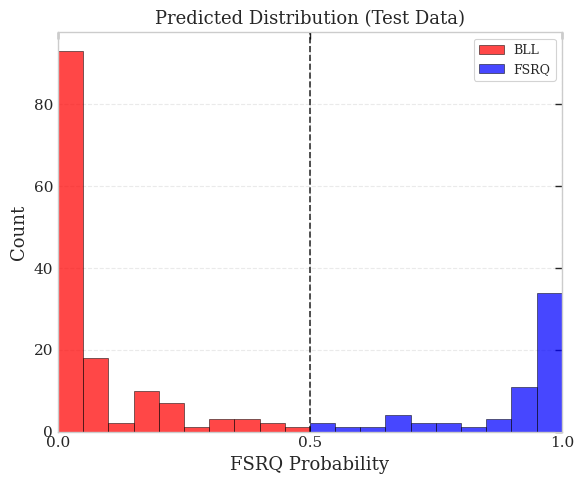

In [13]:
create_and_plot_histograms_test_csv(
    test_csv_path='./agarwal_outputs/Agarwal_Test_Predictions.csv',
    title='Predicted Distribution (Test Data)',
    save_path='./agarwal_outputs/Agarwal_Test_histogram.png',
)


BLL count : 770
FSRQ count: 345


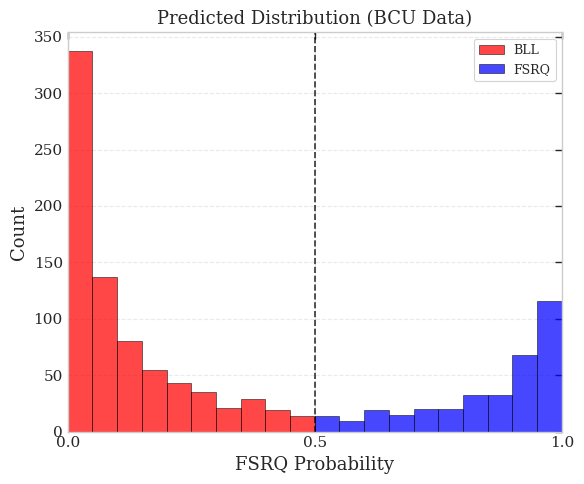

In [14]:
create_and_plot_histograms_test_csv(
    test_csv_path='./agarwal_outputs/Agarwal_BCU_Predictions.csv',
    title='Predicted Distribution (BCU Data)',
    save_path='./agarwal_outputs/Agarwal_BCU_histogram.png',
)

Requested alpha : 0.1
Using alpha     : 0.1
qhat_BLL        : 0.3139386475086212
qhat_FSRQ       : 0.6804883778095245

Prediction-set counts at fixed alpha
BLL only : 132
FSRQ only: 69
Both set : 0
Empty set: 0
Total    : 201


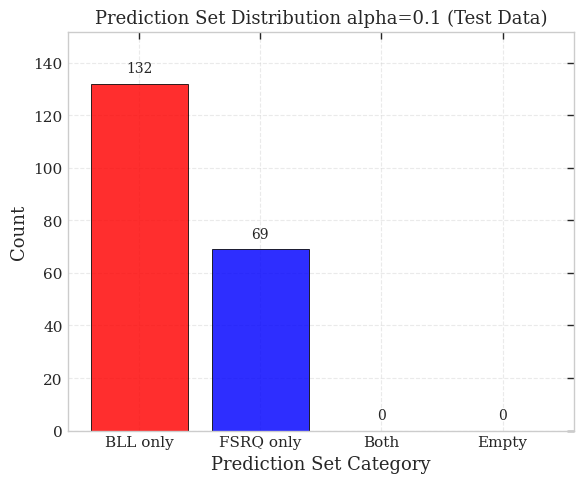

In [15]:
results = analyze_prediction_sets(
    qhat_csv='./agarwal_outputs/agarwal_qhat_mccp.csv',
    test_csv='./agarwal_outputs/Agarwal_Test_Predictions.csv',
    alpha_target=0.1,
    save_path='./agarwal_outputs/Agarwal_Test_prediction_set_distribution_alpha.png',
    title="Prediction Set Distribution alpha=0.1 (Test Data)",
)


Requested alpha : 0.1
Using alpha     : 0.1
qhat_BLL        : 0.3139386475086212
qhat_FSRQ       : 0.6804883778095245

Prediction-set counts at fixed alpha
BLL only : 694
FSRQ only: 418
Both set : 0
Empty set: 3
Total    : 1115


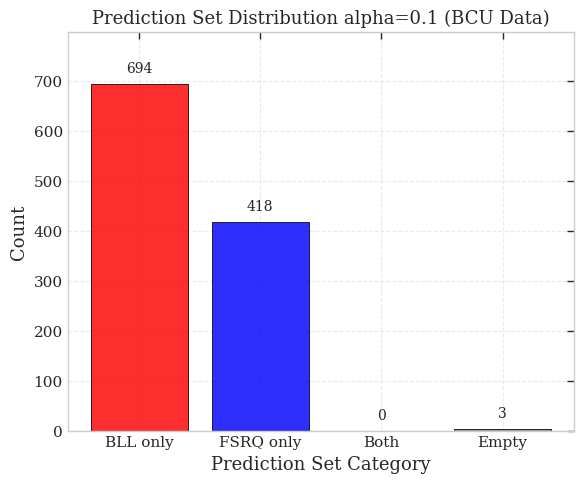

In [16]:
results_bcu = analyze_prediction_sets(
    qhat_csv='./agarwal_outputs/agarwal_qhat_mccp.csv',
    test_csv='./agarwal_outputs/Agarwal_BCU_Predictions.csv',
    alpha_target=0.1,
    save_path='./agarwal_outputs/Agarwal_BCU_prediction_set_distribution_alpha.png',
    title="Prediction Set Distribution alpha=0.1 (BCU Data)",
)

In [17]:
prefix = "Agarwal"
alpha = 0.1
random_state = 0

def save_plot_bundle(mcp, output_dir, prefix=prefix, include_fig2_scatter=True):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    mcp.plot_all(
        output_dir=str(output_dir),
        prefix=prefix,
        show=False,
        include_fig2_scatter=include_fig2_scatter,
    )

    png_plotters = [
        ("coverage", mcp.plot_coverage),
        ("setsize", mcp.plot_set_size),
        ("roc", mcp.plot_roc),
        ("alpha_metrics", mcp.plot_alpha_metrics),
    ]
    if include_fig2_scatter:
        png_plotters.append(("scatter", mcp.plot_prediction_set_scatter))

    for name, plotter in png_plotters:
        plotter(save_path=output_dir / f"{prefix}_{name}.png", show=False)
        

['FSRQ' 'BLL']
['true_label', 'BLL', 'FSRQ']
Qhat rows   : 52 alpha values
Test        : 201 samples
Classes     : ['BLL', 'FSRQ']

Running unified alpha sweep …
Computing macro ROC …

Macro AUC = 0.9566 | MCP AUC ≈ 0.9539

-----------------------------------------------
  MCP Metrics Summary   alpha = 0.1000
-----------------------------------------------
  Calibration samples : 1604
  Test samples        : 201
  Classes             : 2
-----------------------------------------------
  Coverage            : 0.8706   (target >= 0.9000)
  Macro F1-score      : 0.8510
  Average set size    : 1.0000
  Singleton rate      : 0.8706
  True positive rate  : 0.8706
  False positive rate : 0.1294
-----------------------------------------------
  Per-class F1:
    BLL                          0.9051
    FSRQ                         0.7969
-----------------------------------------------
  Saved: agarwal_outputs/Agarwal_coverage.pdf
  Saved: agarwal_outputs/Agarwal_setsize.pdf
  Saved: agarwal_out

alpha                0.100000
n_cal             1604.000000
n_test             201.000000
n_classes            2.000000
coverage             0.870647
macro_f1             0.850992
avg_set_size         1.000000
singleton_rate       0.870647
fpr                  0.129353
tpr                  0.870647
dtype: float64

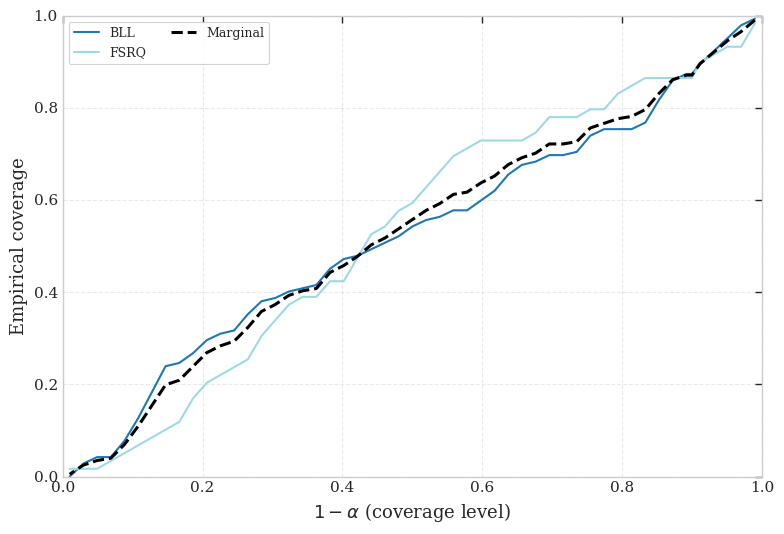

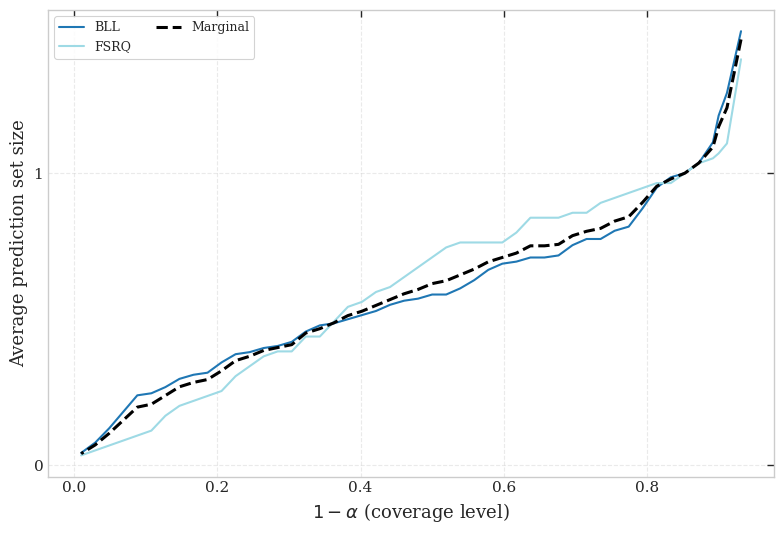

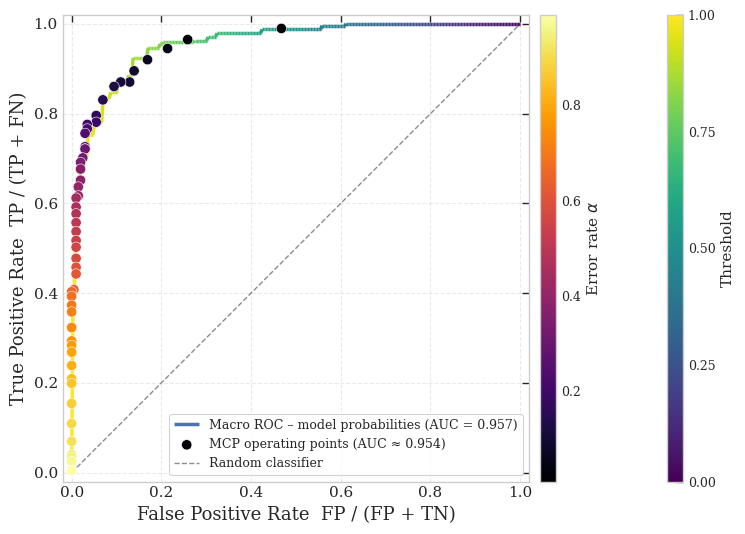

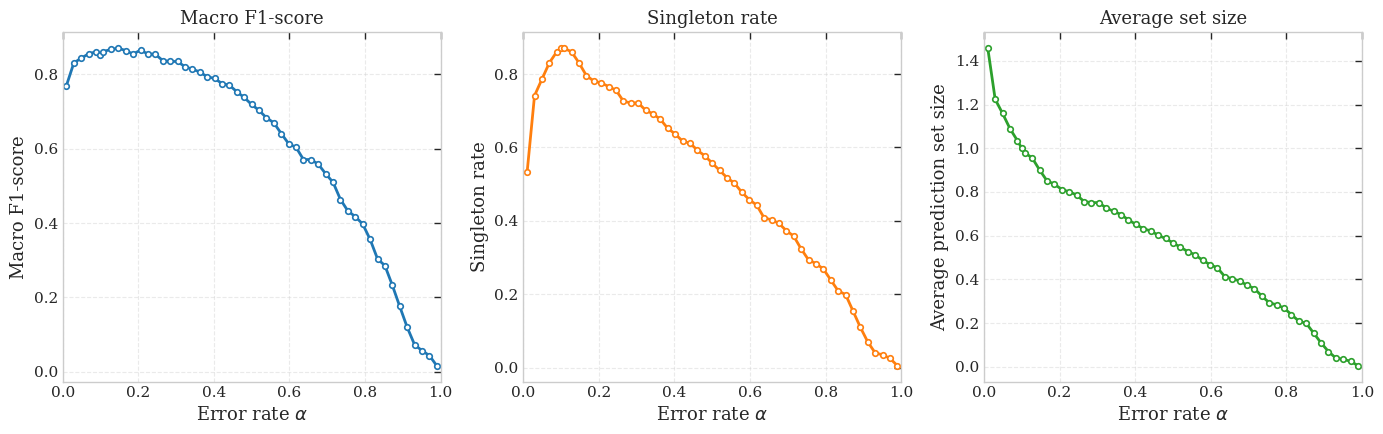

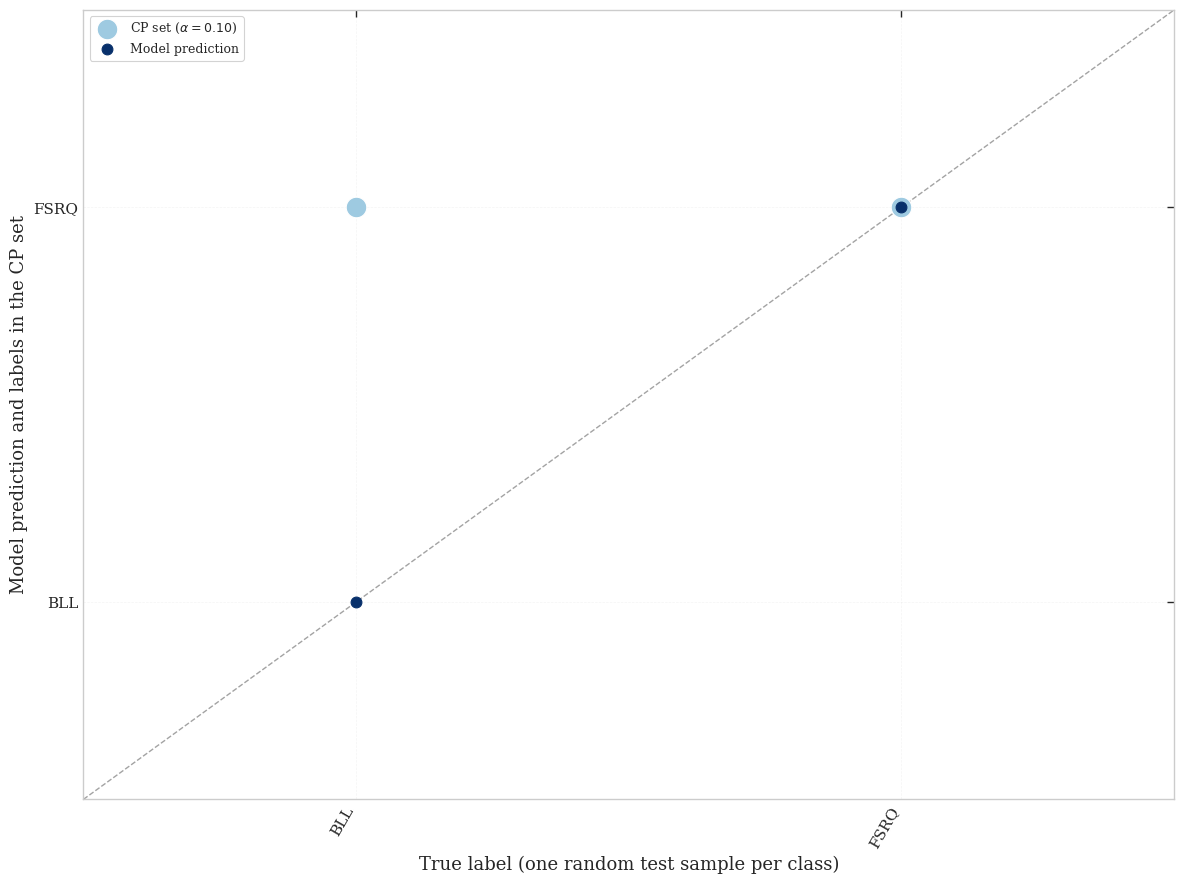

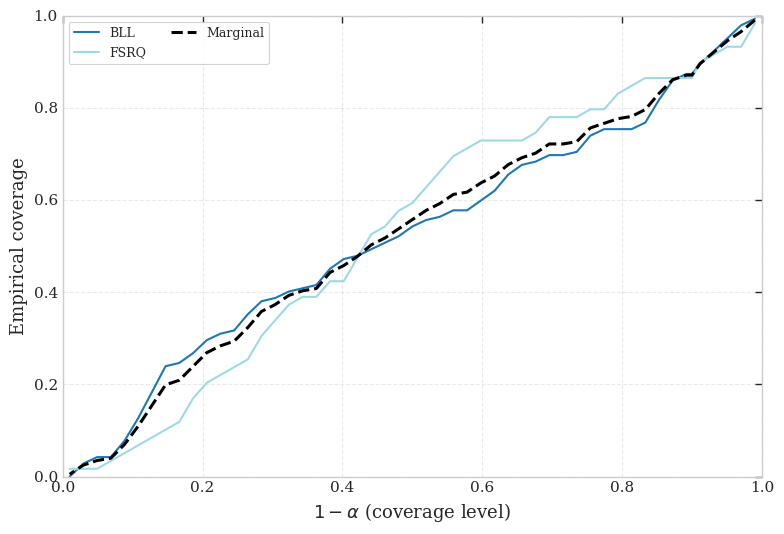

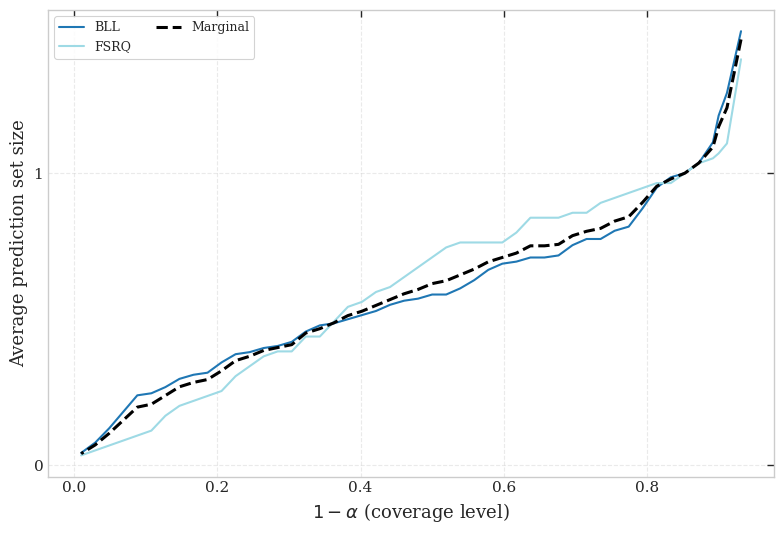

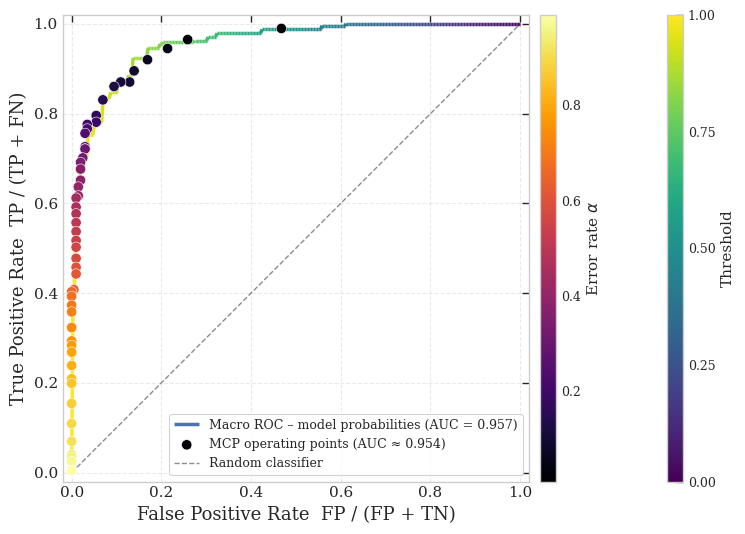

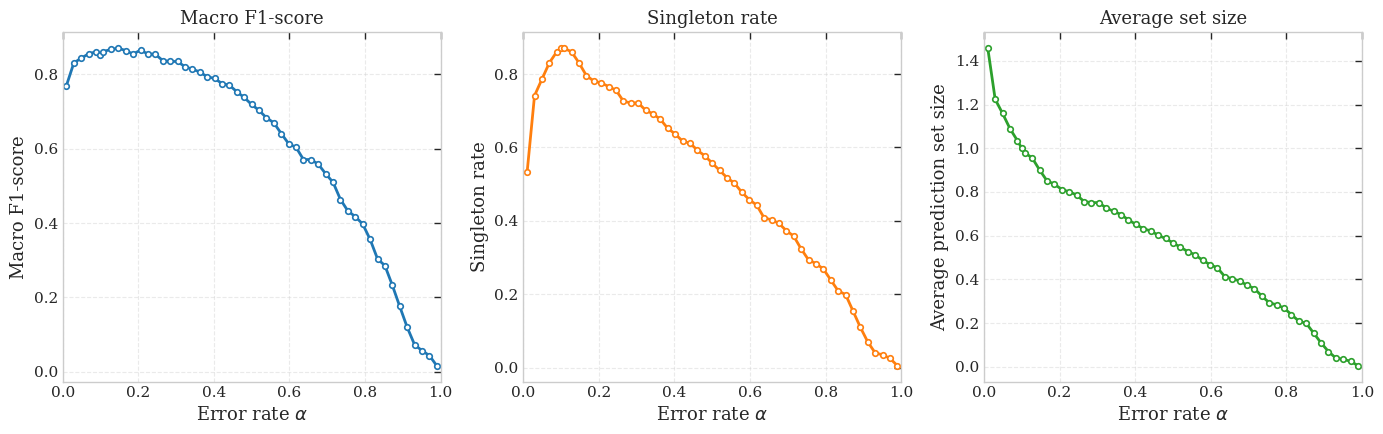

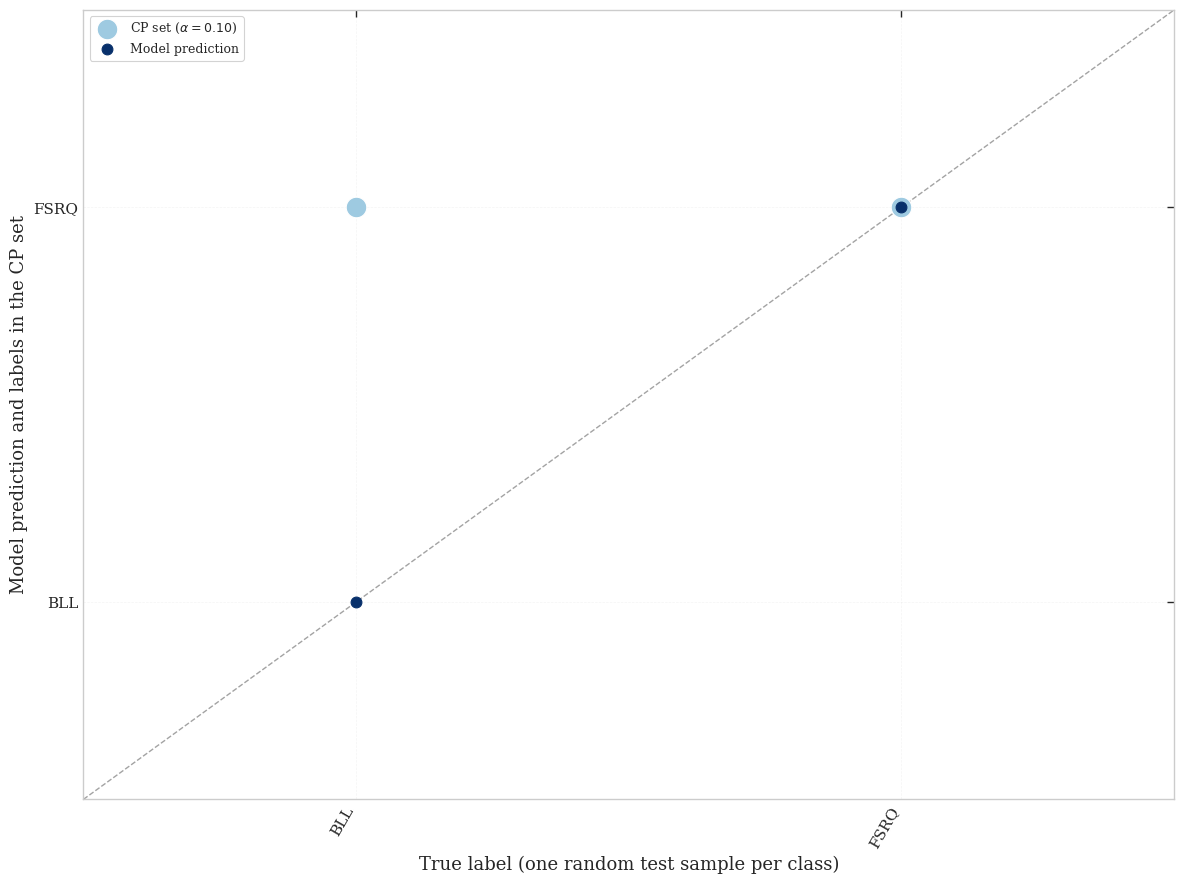

In [18]:
qhat_csv = './agarwal_outputs/agarwal_qhat_mccp.csv'
test_csv = './agarwal_outputs/Agarwal_Test_Predictions.csv'

test_df = pd.read_csv(test_csv)

print(test_df["true_label"].unique())   # should already show ['BLL', 'FSRQ'] or ['FSRQ', 'BLL']
print(test_df.columns.tolist())         # should show ['true_label', 'BLL', 'FSRQ']

mcp_qhat = MCPTool.from_qhat_csv(
    qhat_csv,
    test_csv,
    alpha=alpha,
    random_state=random_state,
).run()

save_plot_bundle(mcp_qhat, OUTPUT_DIR)

summary = mcp_qhat.print_metrics()
pd.Series({k: v for k, v in summary.items() if k != "per_label_f1"})